In [1]:
import copy
import datetime as dt
from datetime import datetime
import importlib  # needed so that we can reload packages
import logging
import os
import pathlib
import sys
import time
import warnings
from typing import Union, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from utils.logger_utils import setup_clean_logger, mute_external_loggers

# SISEPUEDE imports
from sisepuede.manager.sisepuede_examples import SISEPUEDEExamples
from sisepuede.manager.sisepuede_file_structure import SISEPUEDEFileStructure
import sisepuede.core.support_classes as sc
import sisepuede.utilities._plotting as spu
import sisepuede.utilities._toolbox as sf
import sisepuede.core.attribute_table as att
import sisepuede.manager.sisepuede_examples as sxl
import sisepuede.manager.sisepuede_file_structure as sfs
import sisepuede.manager.sisepuede_models as sm
import sisepuede.visualization.plots as svp



# --- Runtime configuration ---
warnings.filterwarnings("ignore")

# Set up a clean logger for your notebook
logger = setup_clean_logger("notebook", logging.INFO)
logger.info("Notebook started successfully.")

# Mute logs from sisepuede to avoid duplication
mute_external_loggers(["sisepuede"])


2026-03-11 22:31:51,650 - INFO - Notebook started successfully.


In [2]:
%load_ext autoreload
%autoreload 2

### Initial Set up

Make sure to edit the config yaml under ssp_modeling/config_files/config.yaml

You can also create a new config yaml



In [3]:
# Set up dir paths

CURR_DIR_PATH = pathlib.Path(os.getcwd())
SSP_MODELING_DIR_PATH = CURR_DIR_PATH.parent
PROJECT_DIR_PATH = SSP_MODELING_DIR_PATH.parent
DATA_DIR_PATH = SSP_MODELING_DIR_PATH.joinpath("input_data")
RUN_OUTPUT_DIR_PATH = SSP_MODELING_DIR_PATH.joinpath("ssp_run_output")
SCENARIO_MAPPING_DIR_PATH = SSP_MODELING_DIR_PATH.joinpath("scenario_mapping")
CONFIG_DIR_PATH = CURR_DIR_PATH.joinpath("config_files")
TRANSFORMATIONS_DIR_PATH = SSP_MODELING_DIR_PATH.joinpath("transformations")
MISC_DIR_PATH = SSP_MODELING_DIR_PATH.joinpath("misc")
STRATEGIES_DEFINITIONS_FILE_PATH = TRANSFORMATIONS_DIR_PATH.joinpath("strategy_definitions.csv")
STRATEGY_MAPPING_FILE_PATH = MISC_DIR_PATH.joinpath("strategy_mapping.yaml")

In [4]:
from ssp_transformations_handler.GeneralUtils import GeneralUtils
from ssp_transformations_handler.TransformationUtils import TransformationYamlProcessor, StrategyCSVHandler

# Initialize general utilities
g_utils = GeneralUtils()

In [5]:
# Load config file, double check your parameters are correct

YAML_FILE_PATH = os.path.join(CONFIG_DIR_PATH, "config.yaml")
config_params = g_utils.read_yaml(YAML_FILE_PATH)

country_name = config_params['country_name']
ssp_input_file_name = config_params['ssp_input_file_name']
ssp_transformation_cw = config_params['ssp_transformation_cw']
energy_model_flag = config_params['energy_model_flag']
set_lndu_reallocation_factor_to_zero_flag = config_params['set_lndu_reallocation_factor_to_zero']
sim_end_year = config_params.get('sim_end_year', 2050)  # Default to 2050 if not specified

# Print config parameters
logger.info(f"Country name: {country_name}")
logger.info(f"SSP input file name: {ssp_input_file_name}")
logger.info(f"SSP transformation CW: {ssp_transformation_cw}")
logger.info(f"Energy model flag: {energy_model_flag}")
logger.info(f"Set lndu reallocation factor to zero flag: {set_lndu_reallocation_factor_to_zero_flag}")
logger.info(f"Simulation end year: {sim_end_year}")

2026-03-11 22:31:51,751 - INFO - Country name: libya
2026-03-11 22:31:51,752 - INFO - SSP input file name: sisepuede_raw_inputs_latest_LBY_modified_march_2026.csv
2026-03-11 22:31:51,752 - INFO - SSP transformation CW: ssp_libya_transformation_cw_20260310.xlsx
2026-03-11 22:31:51,752 - INFO - Energy model flag: True
2026-03-11 22:31:51,752 - INFO - Set lndu reallocation factor to zero flag: True
2026-03-11 22:31:51,752 - INFO - Simulation end year: 2050


In [6]:
def get_file_structure(
    y0: int = 2015,
    y1: int = sim_end_year,
) -> Tuple[sfs.SISEPUEDEFileStructure, att.AttributeTable]:
    """Get the SISEPUEDE File Structure and update the attribute table
        with new years.
    """
    # setup some SISEPUEDE variables and update time period
    file_struct = sfs.SISEPUEDEFileStructure(
        initialize_directories = False,
    )
 
    # get some keys
    key_time_period = file_struct.model_attributes.dim_time_period
    key_year = file_struct.model_attributes.field_dim_year
 
 
    ##  BUILD THE ATTRIBUTE AND UPDATE
 
    # setup the new attribute table
    years = np.arange(y0, y1 + 1, ).astype(int)
    attribute_time_period = att.AttributeTable(
        pd.DataFrame(
            {
                key_time_period: range(len(years)),
                key_year: years,
            }
        ),
        key_time_period,
    )
 
    # finally, update the ModelAttributes inside the file structure
    (
        file_struct
        .model_attributes
        .update_dimensional_attribute_table(
            attribute_time_period,
        )
    )
 
    # return the tuple
    out = (file_struct, attribute_time_period, )
 
    return out


In [7]:
# Set up SSP objects
INPUT_FILE_PATH = DATA_DIR_PATH.joinpath(ssp_input_file_name)

# model attributes and associated support classes
_EXAMPLES = sxl.SISEPUEDEExamples()
_FILE_STRUCTURE, _ATTRIBUTE_TABLE_TIME_PERIOD = get_file_structure(y1=sim_end_year)
matt = _FILE_STRUCTURE.model_attributes
regions = sc.Regions(matt, )
time_periods = sc.TimePeriods(matt, )
 

### Making sure our input file has the correct format and correct columns
We use an example df with the complete fields and correct format to make sure our file is in the right shape

In [8]:
##  BUILD BASE INPUTS
df_inputs_raw = pd.read_csv(INPUT_FILE_PATH)

# pull example data to fill in gaps
df_example_input = _EXAMPLES("input_data_frame")

In [9]:
# Double checking that our df is in the correct shape (Empty sets should be printed to make sure everything is Ok!)
g_utils.compare_dfs(df_example_input, df_inputs_raw)

Columns in df_example but not in df_input: {'region'}
Columns in df_input but not in df_example: {'iso_alpha_3', 'year'}


In [10]:
all_fields = matt.all_variable_fields_input
df_fiels = df_inputs_raw.columns.tolist()
missing_fields = list(set(all_fields) - set(df_fiels))
print("Missing fields in the input data frame:")
print(missing_fields)

Missing fields in the input data frame:
[]


In [11]:
# Ensure if time_period field exist
if 'time_period' not in df_inputs_raw.columns:
    logger.info("Adding 'time_period' column to df_inputs_raw")
    df_inputs_raw = df_inputs_raw.rename(columns={'period':'time_period'})
else:
    logger.info("'time_period' column already exists in df_inputs_raw")

2026-03-11 22:31:52,485 - INFO - 'time_period' column already exists in df_inputs_raw


In [12]:
# Fixes differences and makes sure that our df is in the correct format.
# Note: Edit this if you need more changes in your df

df_inputs_raw_complete = g_utils.add_missing_cols(df_example_input, df_inputs_raw.copy())
df_inputs_raw_complete.head()

,year,ef_ippu_tonne_nf3_per_tonne_production_chemicals,ef_ippu_tonne_nf3_per_tonne_production_electronics,ef_ippu_tonne_sf6_per_mmm_gdp_other_product_manufacturing,ef_ippu_tonne_sf6_per_tonne_production_chemicals,ef_ippu_tonne_sf6_per_tonne_production_electronics,ef_ippu_tonne_sf6_per_tonne_production_metals,frac_agrc_bevs_and_spices_cl2_dry,frac_agrc_cereals_cl2_dry,frac_agrc_fibers_cl2_dry,...,nemomod_entc_scalar_availability_factor_pp_nuclear,nemomod_entc_scalar_availability_factor_pp_ocean,nemomod_entc_scalar_availability_factor_pp_oil,nemomod_entc_scalar_availability_factor_pp_solar,nemomod_entc_scalar_availability_factor_pp_waste_incineration,nemomod_entc_scalar_availability_factor_pp_wind,iso_alpha_3,population_gnrl_rural,population_gnrl_urban,region
0,2015,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,1.0,1.0,1.0,1.0,1.0,LBY,795843.0,5735976.0,costa_rica
1,2016,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,1.0,1.0,1.0,1.0,1.0,LBY,808058.0,5824068.0,costa_rica
2,2017,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,1.0,1.0,1.0,1.0,1.0,LBY,821006.0,5917764.0,costa_rica
3,2018,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,1.0,1.0,1.0,1.0,1.0,LBY,834319.0,6014736.0,costa_rica
4,2019,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,1.0,1.0,1.0,1.0,1.0,LBY,846496.0,6104537.0,costa_rica


In [13]:
# Double checking that our df is in the correct shape (Empty sets should be printed to make sure everything is Ok!)
g_utils.compare_dfs(df_example_input, df_inputs_raw_complete)

Columns in df_example but not in df_input: set()
Columns in df_input but not in df_example: {'iso_alpha_3', 'year'}


In [14]:
df_inputs_raw_complete["region"].head()

0    costa_rica
1    costa_rica
2    costa_rica
3    costa_rica
4    costa_rica
Name: region, dtype: object

In [15]:
# Set region to country name
df_inputs_raw_complete['region'] = country_name
df_inputs_raw_complete['region'].head()

0    libya
1    libya
2    libya
3    libya
4    libya
Name: region, dtype: object

In [16]:
# filter to match sim_end_year
print(f"min and max years in raw inputs before filtering: {df_inputs_raw_complete['year'].min()} to {df_inputs_raw_complete['year'].max()}")
df_inputs_raw_complete = df_inputs_raw_complete[df_inputs_raw_complete['year'] <= sim_end_year]
print(f"min and max years in raw inputs after filtering: {df_inputs_raw_complete['year'].min()} to {df_inputs_raw_complete['year'].max()}")

min and max years in raw inputs before filtering: 2015 to 2070
min and max years in raw inputs after filtering: 2015 to 2050


#  Let's try building transformations using this


In [17]:
import sisepuede.transformers as trf
transformers = trf.transformers.Transformers(
    {},
    attr_time_period = _ATTRIBUTE_TABLE_TIME_PERIOD,
    df_input = df_inputs_raw_complete,
)

##  Instantiate some transformations. Make sure to run this cell to create the transformations folder for the first time or if you wish to overwrite

In [18]:
# set an ouput path and instantiate
if not TRANSFORMATIONS_DIR_PATH.exists():
    trf.instantiate_default_strategy_directory(
        transformers,
        TRANSFORMATIONS_DIR_PATH,
    )
else:
    logger.info(f"Directory {TRANSFORMATIONS_DIR_PATH} already exists. Skipping instantiation.")


2026-03-11 22:31:52,983 - INFO - Directory /Users/fabianfuentes/git/ssp_libya/ssp_modeling/transformations already exists. Skipping instantiation.


### Customizing transformations and strategies files using TransformationUtils.py classes

In [19]:
# Temporary fix to add a parameter to the yaml files
from ruamel.yaml import YAML
yaml = YAML()
# tell it to keep your original quoting
yaml.preserve_quotes = True

def add_parameter_to_yaml_file(yaml_file_path, parameter_key, parameter_value):
   
    with open(yaml_file_path, 'r') as f:
        data = yaml.load(f)              # <-- ruamel.yaml keeps your formatting

        if 'parameters' not in data:
            raise ValueError(f"{yaml_file_path!r} has no ‘parameters’ key")
        
        data['parameters'][parameter_key] = parameter_value  # add your key

        with open(yaml_file_path, 'w') as f:
            yaml.dump(data, f)               # <-- dumps with the *same* quotes, indents, folds

In [20]:
# Set up the strategy codes you wish to run in ssp
strategies_to_run = [0, 3000,6002]

### We finished adding new transformation files and strategies so lets load them back

In [21]:
# then, you can load this back in after modifying (play around with it)
transformations = trf.Transformations(
    TRANSFORMATIONS_DIR_PATH,
    transformers = transformers,
)
tab = transformations.attribute_transformation.table

In [22]:
#  build the strategies -- will export to path
t0 = time.time()
strategies = trf.Strategies(
    transformations,
    export_path = "transformations",
    prebuild = True,
)

t_elapse = sf.get_time_elapsed(t0)
print(f"Strategies defined at {strategies.transformations.dir_init} initialized in {t_elapse} seconds")

Strategies defined at /Users/fabianfuentes/git/ssp_libya/ssp_modeling/transformations initialized in 28.49 seconds


In [23]:
strategies.attribute_table

,strategy_id,strategy_code,strategy,description,transformation_specification,baseline_strategy_id
0,0,BASE,Strategy TX:BASE,NaN,TX:BASE,1
1,1000,AGRC:DEC_CH4_RICE,Singleton - Default Value - AGRC: Improve rice...,NaN,TX:AGRC:DEC_CH4_RICE,0
2,1001,AGRC:DEC_EXPORTS,Singleton - Default Value - AGRC: Decrease Exp...,NaN,TX:AGRC:DEC_EXPORTS,0
3,1002,AGRC:DEC_LOSSES_SUPPLY_CHAIN,Singleton - Default Value - AGRC: Reduce suppl...,NaN,TX:AGRC:DEC_LOSSES_SUPPLY_CHAIN,0
4,1003,AGRC:INC_CONSERVATION_AGRICULTURE,Singleton - Default Value - AGRC: Expand conse...,NaN,TX:AGRC:INC_CONSERVATION_AGRICULTURE,0
...,...,...,...,...,...,...
139,6068,WHIRLPOOL:TX:WASO:INC_CAPTURE_BIOGAS,Remove TX:WASO:INC_CAPTURE_BIOGAS from All Act...,NaN,TX:AGRC:DEC_CH4_RICE|TX:AGRC:DEC_EXPORTS|TX:AG...,0
140,6069,WHIRLPOOL:TX:WASO:INC_ENERGY_FROM_BIOGAS,Remove TX:WASO:INC_ENERGY_FROM_BIOGAS from All...,NaN,TX:AGRC:DEC_CH4_RICE|TX:AGRC:DEC_EXPORTS|TX:AG...,0
141,6070,WHIRLPOOL:TX:WASO:INC_ENERGY_FROM_INCINERATION,Remove TX:WASO:INC_ENERGY_FROM_INCINERATION fr...,NaN,TX:AGRC:DEC_CH4_RICE|TX:AGRC:DEC_EXPORTS|TX:AG...,0
142,6071,WHIRLPOOL:TX:WASO:INC_LANDFILLING,Remove TX:WASO:INC_LANDFILLING from All Actions,NaN,TX:AGRC:DEC_CH4_RICE|TX:AGRC:DEC_EXPORTS|TX:AG...,0


##  Build our templates
- let's use the default variable groupings for LHS

In [24]:
# Building excel templates, make sure to include the strategies ids in the strategies attribute as well as the baseline (0)
df_vargroups = _EXAMPLES("variable_trajectory_group_specification")

strategies.build_strategies_to_templates(
    # df_trajgroup = df_vargroups,
    # include_simplex_group_as_trajgroup = True,
    strategies = strategies_to_run,
)

0

## How to Run a specific strategy using .project()

In [25]:
# # How to run a specific strategy
# strategy_6003 = strategies.get_strategy(6003)
# strategy_6003()

In [26]:
# strategy_6003().to_csv("libya_input_data_strategy_6003.csv", index=False)

In [27]:
# df_out_strategy_6003 = models.project(strategy_6003(), time_periods_base=range(12))

In [28]:
# import sisepuede.visualization.plots as svp

In [29]:
# df_out_strategy_6003[[col for col in df_out_strategy_6003.columns if "emission_co2e_subsector" in col]].head()

In [30]:
# df_out_strategy_6003.to_csv("libya_output_strategy_6003.csv", index=False)

In [31]:
# fig, ax = plt.subplots(figsize = (13, 7))
# svp.plot_emissions_stack(df_out_strategy_6003, matt, figtuple = (fig, ax))
# ax.legend()

In [32]:
# df_out_strategy_6003[[col for col in df_out_strategy_6003.columns if "exportsadj" in col and "enfu" in col]].iloc[10]

In [33]:
# df_out_strategy_6004[[col for col in df_out_strategy_6004.columns if "exportsadj" in col and "enfu" in col]].iloc[-1]

In [34]:
# strat0 = strategies.get_strategy(0)
# df0 = strat0()

# df0_ssp = ssp.generate_scenario_database_from_primary_key(0)
# df0_ssp = df0_ssp.get("libya")

# for k in df0.columns:
#     if k not in df0_ssp.columns:
#         print(f"skipping {k}...")
#         continue

#     if isinstance(df0[k].iloc[0], str): continue

#     vec_from_strat = df0[k].to_numpy()
#     vec_from_ssp = df0_ssp[k].to_numpy()

#     eps = np.nan_to_num(
#         (vec_from_ssp - vec_from_strat)/vec_from_ssp,
#         posinf = 1.0,
#         nan = 0.0
#     )

#     eps = np.abs(eps)

#     if eps.max() > 0.0001:
#         print(f"check field {k}")

# Finally, load SISEPUEDE and run it

In [35]:
country_name

'libya'

In [36]:
import sisepuede as si
# timestamp_str = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
ssp = si.SISEPUEDE(
    "calibrated",
    db_type = "csv",
    # id_str = f"sisepuede_run_2024-11-04T09:23:26.721580",
    initialize_as_dummy = not(energy_model_flag), # no connection to Julia is initialized if set to True
    regions = [country_name],
    strategies = strategies,
    # try_exogenous_xl_types_in_variable_specification = True,
    attribute_time_period=_ATTRIBUTE_TABLE_TIME_PERIOD
)

2026-03-11 22:32:25,283 - INFO - Successfully initialized SISEPUEDEFileStructure.
2026-03-11 22:32:25,284 - WARNING - Missing key dict_dimensional_keys: key time_series not found. Tables that rely on the time_series will not have index checking.
2026-03-11 22:32:25,284 - INFO - 	Setting export engine to 'csv'.
2026-03-11 22:32:25,285 - WARNING - No index fields defined. Index field values will not be checked when writing to tables.
2026-03-11 22:32:25,285 - INFO - Successfully instantiated table ANALYSIS_METADATA
2026-03-11 22:32:25,285 - WARNING - No index fields found in ATTRIBUTE_DESIGN. Initializing index fields.
2026-03-11 22:32:25,285 - INFO - Successfully instantiated table ATTRIBUTE_DESIGN
2026-03-11 22:32:25,285 - WARNING - No index fields found in ATTRIBUTE_LHC_SAMPLES_EXOGENOUS_UNCERTAINTIES. Initializing index fields.
2026-03-11 22:32:25,286 - INFO - Successfully instantiated table ATTRIBUTE_LHC_SAMPLES_EXOGENOUS_UNCERTAINTIES
2026-03-11 22:32:25,286 - WARNING - No index fi

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


Precompiling NemoMod...
Info Given NemoMod was explicitly requested, output will be shown live 
ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.
   1338.8 ms  ? NemoMod
[ Info: Precompiling NemoMod [a3c327a0-d2f0-11e8-37fd-d12fd35c3c72] 
ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.
┌ Info: Skipping precompilation due to precompilable error. Importing NemoMod [a3c327a0-d2f0-11e8-37fd-d12fd35c3c72].
└   exception = Error when precompiling module, potentially caused by a __precompile__(false) declaration in the module.
2026-03-11 22:33:03,430 - INFO - Successfully initialized JuMP optimizer from solver module HiGHS.
2026-03-11 22:33:03,444 - INFO - Successfully initialized SISEPUEDEModels.
2026-03-11 22:33:03,452 - INFO - Table ANALYSIS_METADATA successfully written to /Users/fabianfuentes/anaconda3/envs/ssp_libya_env_wirlp

In [37]:
not(energy_model_flag)

False

In [38]:
# This runs the model, make sure you edit key_stretegy with the strategy ids you want to execute include baseline (0)
dict_scens = {
    ssp.key_design: [0],
    ssp.key_future: [0],
    ssp.key_strategy: strategies_to_run,
}

ssp.project_scenarios(
    dict_scens,
    save_inputs = True,
    include_electricity_in_energy = energy_model_flag,
    # dict_optimizer_attributes = {"user_bound_scale": -7, }
)

2026-03-11 22:33:03,603 - INFO - 
***	STARTING REGION libya	***

2026-03-11 22:33:04,923 - INFO - Trying run primary_id = 0 in region libya
2026-03-11 22:33:04,924 - INFO - Running AFOLU model
2026-03-11 22:33:05,148 - INFO - AFOLU model run successfully completed
2026-03-11 22:33:05,148 - INFO - Running CircularEconomy model
2026-03-11 22:33:05,172 - INFO - CircularEconomy model run successfully completed
2026-03-11 22:33:05,172 - INFO - Running IPPU model
2026-03-11 22:33:05,210 - INFO - IPPU model run successfully completed
2026-03-11 22:33:05,210 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2026-03-11 22:33:05,221 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2026-03-11 22:33:05,267 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2026-03-11 22:33:05,267 - INFO - Running Energy model (Electricity and Fuel Production: trying to 

2026-11-Mar 22:33:05.677 Opened SQLite database at /Users/fabianfuentes/anaconda3/envs/ssp_libya_env_wirlpool/lib/python3.11/site-packages/sisepuede/tmp/nemomod_intermediate_database.sqlite.
2026-11-Mar 22:33:05.697 Added NEMO structure to SQLite database at /Users/fabianfuentes/anaconda3/envs/ssp_libya_env_wirlpool/lib/python3.11/site-packages/sisepuede/tmp/nemomod_intermediate_database.sqlite.
2026-11-Mar 22:33:21.212 Started modeling scenario. NEMO version = 2.2.0, solver = HiGHS.


2026-03-11 22:34:07,534 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2026-03-11 22:34:07,550 - INFO - EnergyProduction model run successfully completed
2026-03-11 22:34:07,550 - INFO - Running Energy (Fugitive Emissions)
2026-03-11 22:34:07,592 - INFO - Fugitive Emissions from Energy model run successfully completed
2026-03-11 22:34:07,592 - INFO - Appending Socioeconomic outputs
2026-03-11 22:34:07,597 - INFO - Socioeconomic outputs successfully appended.
2026-03-11 22:34:07,601 - INFO - Model run for primary_id = 0 successfully completed in 62.68 seconds (n_tries = 1).
2026-03-11 22:34:07,621 - INFO - Trying run primary_id = 37037 in region libya
2026-03-11 22:34:07,622 - INFO - Running AFOLU model


2026-11-Mar 22:33:21.729 Started optimizing following years: [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010, 1011, 1012].
2026-11-Mar 22:33:39.610 Finished optimizing following years: [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010, 1011, 1012].
2026-11-Mar 22:33:39.694 Started optimizing following years: [1013, 1014, 1015, 1016, 1017, 1018, 1019, 1020, 1021, 1022, 1023, 1024, 1025, 1026, 1027, 1028, 1029, 1030, 1031, 1032, 1033, 1034, 1035].
2026-11-Mar 22:34:07.390 Finished optimizing following years: [1013, 1014, 1015, 1016, 1017, 1018, 1019, 1020, 1021, 1022, 1023, 1024, 1025, 1026, 1027, 1028, 1029, 1030, 1031, 1032, 1033, 1034, 1035].
set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


2026-03-11 22:34:07,845 - INFO - AFOLU model run successfully completed
2026-03-11 22:34:07,845 - INFO - Running CircularEconomy model
2026-03-11 22:34:07,869 - INFO - CircularEconomy model run successfully completed
2026-03-11 22:34:07,869 - INFO - Running IPPU model
2026-03-11 22:34:07,909 - INFO - IPPU model run successfully completed
2026-03-11 22:34:07,910 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2026-03-11 22:34:07,920 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2026-03-11 22:34:07,972 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2026-03-11 22:34:07,972 - INFO - Running Energy model (Electricity and Fuel Production: trying to call Julia)


...

2026-11-Mar 22:34:46.505 Started modeling scenario. NEMO version = 2.2.0, solver = HiGHS.
2026-11-Mar 22:34:46.552 Started optimizing following years: [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010, 1011, 1012].


2026-03-11 22:35:18,234 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2026-03-11 22:35:18,248 - INFO - EnergyProduction model run successfully completed
2026-03-11 22:35:18,248 - INFO - Running Energy (Fugitive Emissions)
2026-03-11 22:35:18,270 - INFO - Fugitive Emissions from Energy model run successfully completed
2026-03-11 22:35:18,270 - INFO - Appending Socioeconomic outputs
2026-03-11 22:35:18,276 - INFO - Socioeconomic outputs successfully appended.
2026-03-11 22:35:18,279 - INFO - Model run for primary_id = 73073 successfully completed in 33.03 seconds (n_tries = 1).
2026-03-11 22:35:18,289 - INFO - 
***	 REGION libya COMPLETE	***



2026-11-Mar 22:34:59.085 Finished optimizing following years: [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010, 1011, 1012].
2026-11-Mar 22:34:59.147 Started optimizing following years: [1013, 1014, 1015, 1016, 1017, 1018, 1019, 1020, 1021, 1022, 1023, 1024, 1025, 1026, 1027, 1028, 1029, 1030, 1031, 1032, 1033, 1034, 1035].
2026-11-Mar 22:35:18.122 Finished optimizing following years: [1013, 1014, 1015, 1016, 1017, 1018, 1019, 1020, 1021, 1022, 1023, 1024, 1025, 1026, 1027, 1028, 1029, 1030, 1031, 1032, 1033, 1034, 1035].
set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


2026-03-11 22:35:18,369 - INFO - Table MODEL_OUTPUT successfully written to /Users/fabianfuentes/anaconda3/envs/ssp_libya_env_wirlpool/lib/python3.11/site-packages/sisepuede/out/sisepuede_run_2026-03-11T22;32;24.975382/sisepuede_run_2026-03-11T22;32;24.975382_output_database/MODEL_OUTPUT.csv.
2026-03-11 22:35:18,371 - INFO - Table ATTRIBUTE_PRIMARY successfully written to /Users/fabianfuentes/anaconda3/envs/ssp_libya_env_wirlpool/lib/python3.11/site-packages/sisepuede/out/sisepuede_run_2026-03-11T22;32;24.975382/sisepuede_run_2026-03-11T22;32;24.975382_output_database/ATTRIBUTE_PRIMARY.csv.
2026-03-11 22:35:18,469 - INFO - Table MODEL_INPUT successfully written to /Users/fabianfuentes/anaconda3/envs/ssp_libya_env_wirlpool/lib/python3.11/site-packages/sisepuede/out/sisepuede_run_2026-03-11T22;32;24.975382/sisepuede_run_2026-03-11T22;32;24.975382_output_database/MODEL_INPUT.csv.


{'libya': [0, 37037, 73073]}

## Read simulations and check outputs

In [39]:
# Read input and output files
df_out = ssp.read_output(None)
df_in = ssp.read_input(None)

In [40]:
def plot_field_stack(
    df,
    fields,
    dict_format,
    time_col="time_period",
    primary_id=0,
    figsize=(18, 8),
    legend_loc='upper right',
    legend_bbox=(1.1, 1),
    ylabel="MT Emissions CO2e",
    xlabel="Time Period",
    title=None,
):
    """
    Plots a stack plot of the selected fields for a given primary_id.

    Args:
        df (pd.DataFrame): DataFrame containing output data.
        fields (list): List of column names to plot.
        dict_format (dict): Formatting dictionary for colors.
        time_col (str): Name of the time column.
        primary_id (int): Value of primary_id to filter.
        figsize (tuple): Figure size.
        legend_loc (str): Legend location.
        legend_bbox (tuple): Legend bbox_to_anchor.
        ylabel (str): Y-axis label.
        xlabel (str): X-axis label.
        title (str): Plot title.
    """
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)

    df_plot = df[df[ssp.key_primary].isin([primary_id])]

    fig, ax = spu.plot_stack(
        df_plot,
        fields,
        dict_formatting=dict_format,
        field_x=time_col,
        figtuple=(fig, ax),
    )

    ax.legend(loc=legend_loc, bbox_to_anchor=legend_bbox, title="Fields")
    plt.show()

In [41]:
# Define the fields to plot and the formatting dictionary
subsector_emission_fields = matt.get_all_subsector_emission_total_fields()

dict_format = dict(
    (k, {"color": v}) for (k, v) in
    matt.get_subsector_color_map().items()
)

In [42]:
primary_ids_to_plot = df_out[ssp.key_primary].unique()

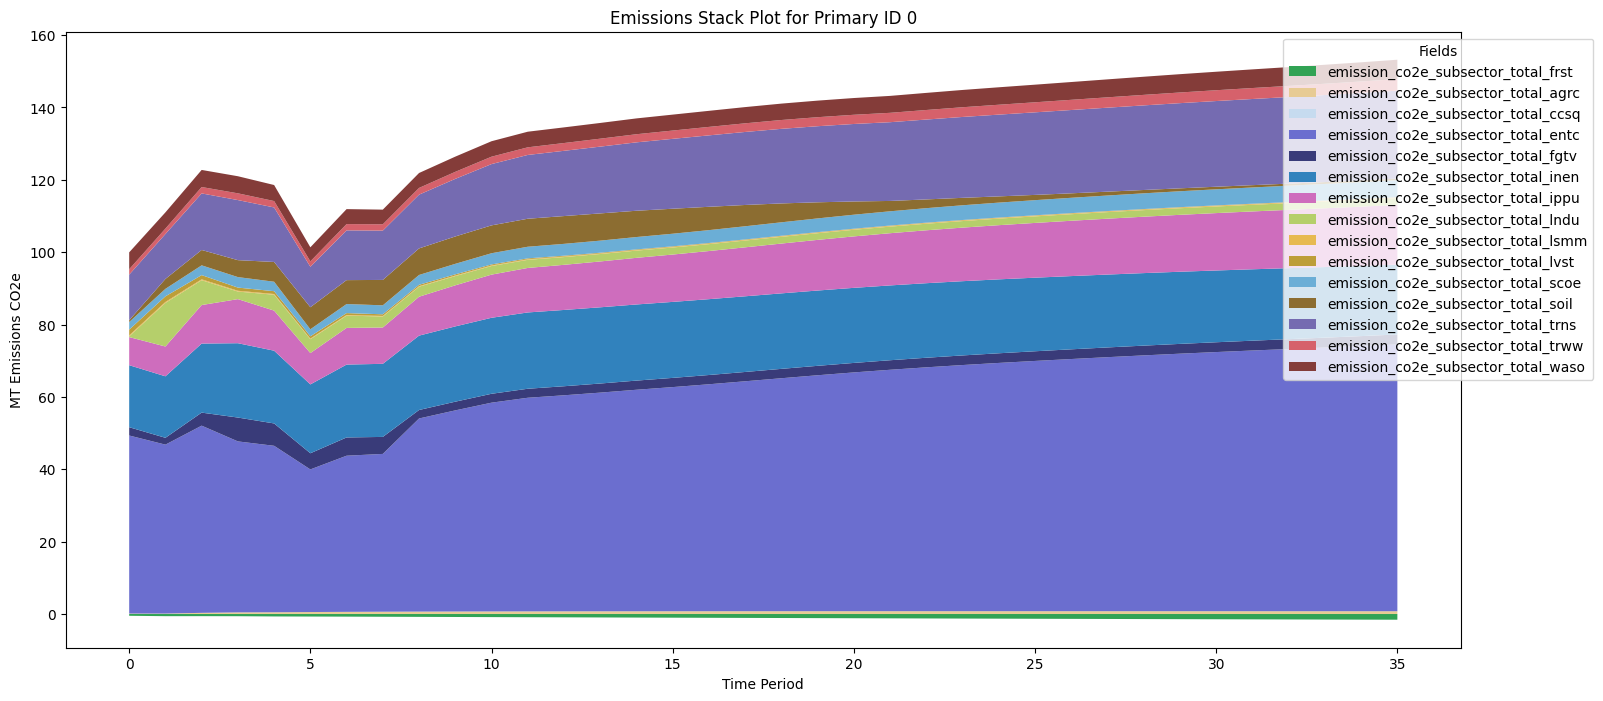

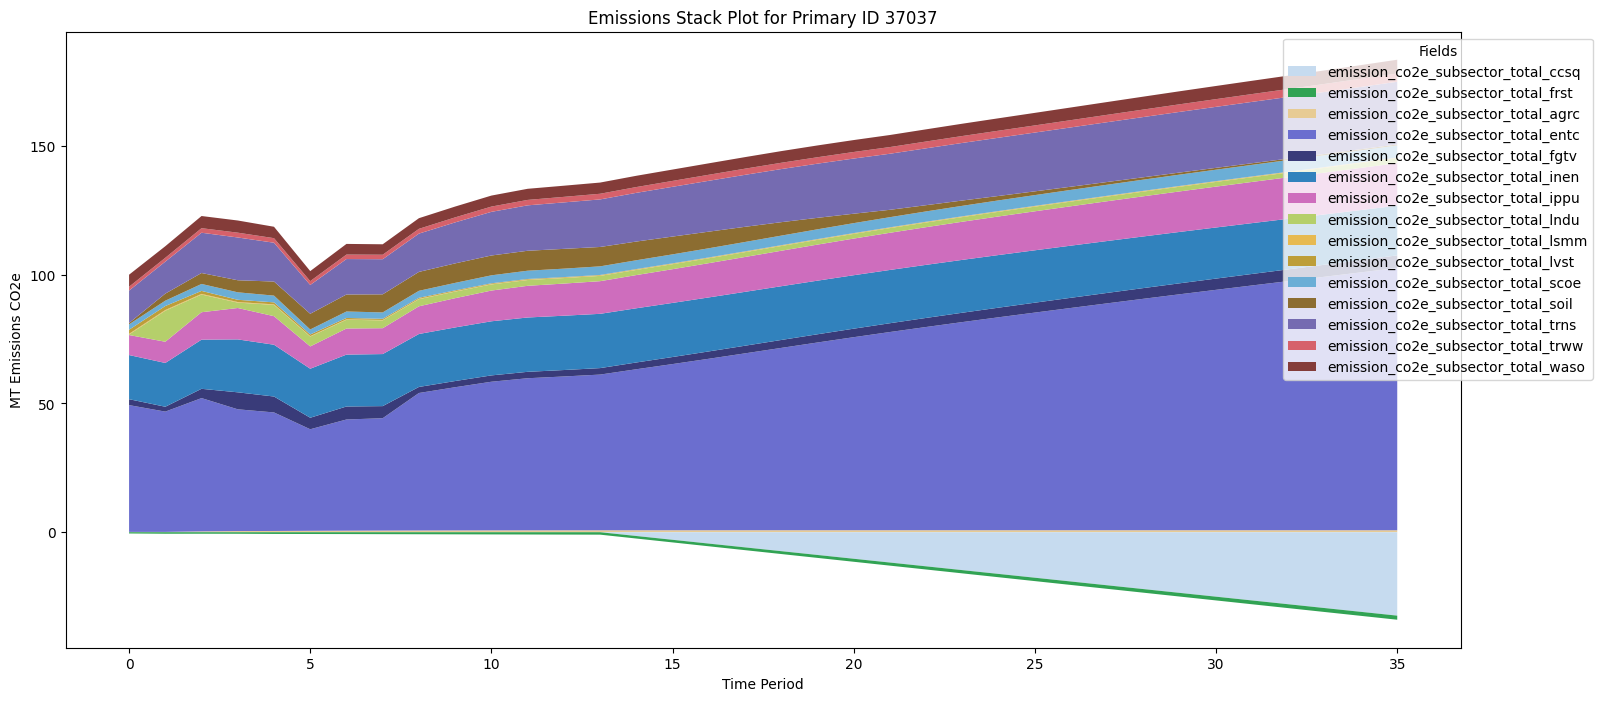

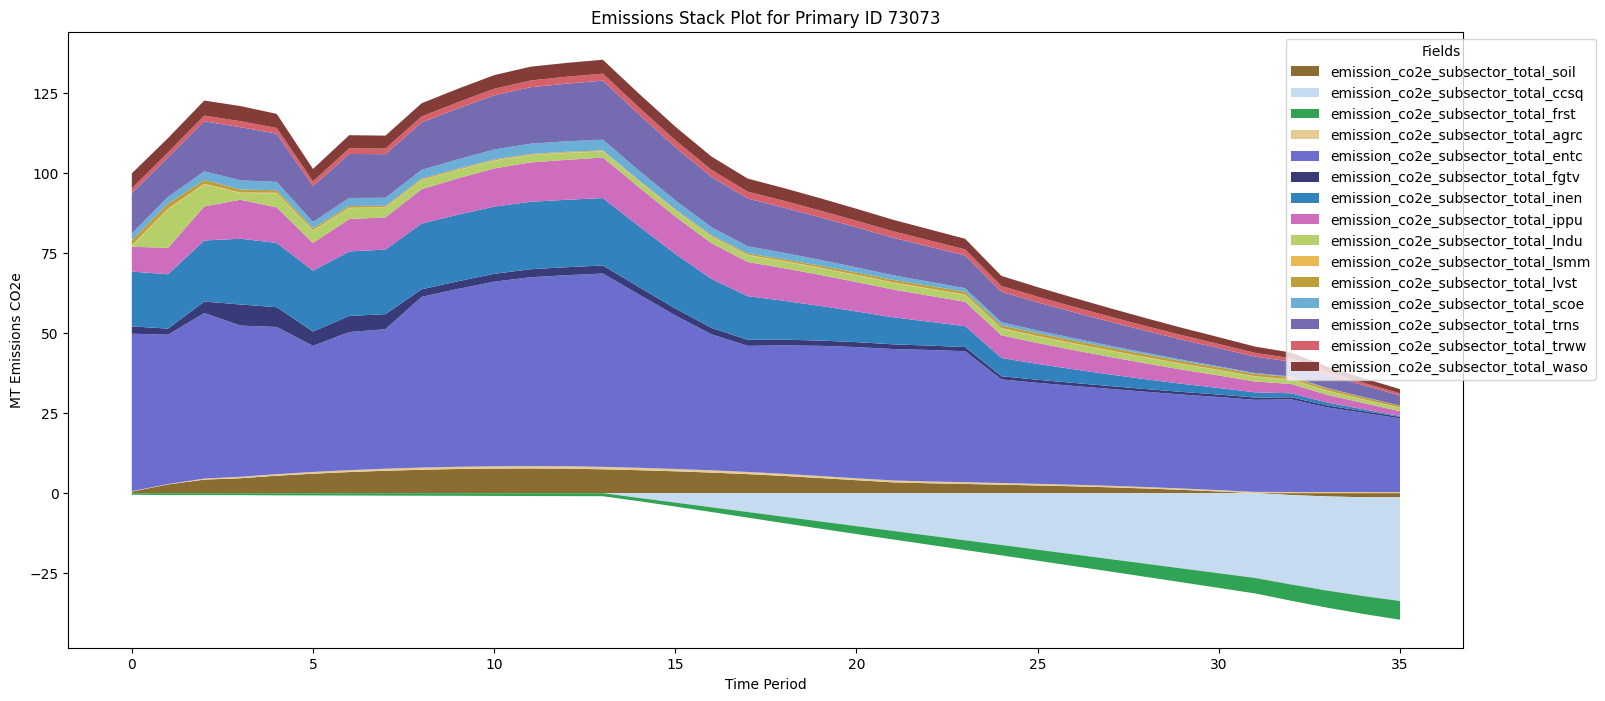

In [43]:
# Plot the emissions stack for the primary_id 0 (which is the baseline)
for primary_id in primary_ids_to_plot:

    plot_field_stack(
        df_out,
        subsector_emission_fields,
        dict_format,
        primary_id=primary_id,
        title=f"Emissions Stack Plot for Primary ID {primary_id}"
    )

# Export Wide File

In [44]:
all_primaries = sorted(list(df_out[ssp.key_primary].unique()))

# build if unable to simply read the data frame
if df_in is None:
    df_in = []
     
    for region in ssp.regions:
        for primary in all_primaries: 
            df_in_filt = ssp.generate_scenario_database_from_primary_key(primary)
            df_in.append(df_in_filt.get(region))
    
    df_in = pd.concat(df_in, axis = 0).reset_index(drop = True)




df_export = pd.merge(
    df_out,
    df_in,
    how = "left",
)



# check output directory 
dir_pkg = os.path.join(
    ssp.file_struct.dir_out, 
    f"sisepuede_summary_results_run_{ssp.id_fs_safe}"
)
os.makedirs(dir_pkg) if not os.path.exists(dir_pkg) else None


for tab in ["ATTRIBUTE_STRATEGY"]:
    table_df = ssp.database.db.read_table(tab)
    if table_df is not None:
        table_df.to_csv(
            os.path.join(dir_pkg, f"{tab}.csv"),
            index=None,
            encoding="UTF-8"
        )
    else:
        print(f"Warning: Table {tab} returned None.")


df_primary = (
    ssp
    .odpt_primary
    .get_indexing_dataframe(
        sorted(list(df_out[ssp.key_primary].unique()))
    )
)
    
df_primary.to_csv(
    os.path.join(dir_pkg, f"ATTRIBUTE_PRIMARY.csv"),
    index = None,
    encoding = "UTF-8"
)

df_export.to_csv(
    os.path.join(dir_pkg, f"sisepuede_results_{ssp.id_fs_safe}_WIDE_INPUTS_OUTPUTS.csv"),
    index = None,
    encoding = "UTF-8"
)

In [45]:
# Getting the directory where the outputs are stored
ssp.file_struct.dir_out

'/Users/fabianfuentes/anaconda3/envs/ssp_libya_env_wirlpool/lib/python3.11/site-packages/sisepuede/out'

In [46]:
RUN_ID_OUTPUT_DIR_PATH = os.path.join(
    RUN_OUTPUT_DIR_PATH, 
    f"sisepuede_results_{ssp.id_fs_safe}"
)

os.makedirs(RUN_ID_OUTPUT_DIR_PATH, exist_ok=True)

df_primary.to_csv(
    os.path.join(RUN_ID_OUTPUT_DIR_PATH, "ATTRIBUTE_PRIMARY.csv"),
    index = None,
    encoding = "UTF-8"
)

df_export.to_csv(
    os.path.join(RUN_ID_OUTPUT_DIR_PATH, f"sisepuede_results_{ssp.id_fs_safe}_WIDE_INPUTS_OUTPUTS.csv"),
    index = None,
    encoding = "UTF-8"
)

for tab in ["ATTRIBUTE_STRATEGY"]:
    table_df = ssp.database.db.read_table(tab)
    if table_df is not None:
        table_df.to_csv(
            os.path.join(RUN_ID_OUTPUT_DIR_PATH, f"{tab}.csv"),
            index=None,
            encoding="UTF-8"
        )
    else:
        logger.warning(f"Warning: Table {tab} returned None.")

In [47]:
RUN_ID_OUTPUT_DIR_PATH

'/Users/fabianfuentes/git/ssp_libya/ssp_modeling/ssp_run_output/sisepuede_results_sisepuede_run_2026-03-11T22;32;24.975382'

## Generate Levers Table

In [48]:
strategies_to_run.remove(0)
strategies_to_run

[3000, 6002]

In [49]:
import sisepuede.visualization.tables as svt
tableau_levers_table = svt.LeversImplementationTable(strategies, )
tableau_levers_table_csv = tableau_levers_table.build_table_for_strategies(
    strategies_to_run
)

tableau_levers_table_csv.head()

,sector,subsector,transformer_code,transformer_name,transformer_description,transformer_unit,maximum_magnitude,strategy_CCSQ_INC_CAPTURE,strategy_PFLO_ALL,year
0,0.0,0.0,TFR:AGRC:DEC_CH4_RICE,0.0,0.0,0.0,0.0,0.0,0.0,2015
1,0.0,0.0,TFR:AGRC:DEC_CH4_RICE,0.0,0.0,0.0,0.0,0.0,0.0,2016
2,0.0,0.0,TFR:AGRC:DEC_CH4_RICE,0.0,0.0,0.0,0.0,0.0,0.0,2017
3,0.0,0.0,TFR:AGRC:DEC_CH4_RICE,0.0,0.0,0.0,0.0,0.0,0.0,2018
4,0.0,0.0,TFR:AGRC:DEC_CH4_RICE,0.0,0.0,0.0,0.0,0.0,0.0,2019


In [50]:
tableau_levers_table_csv.to_csv(os.path.join(RUN_ID_OUTPUT_DIR_PATH, f"levers_implementation_{country_name}.csv"), index=False)